## EDA (Exploratory Data Analysis)

In [3]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Demographic & Customer Profile Analysis

### 1. Does churn vary by gender?

In [5]:
## Churn variation by gender
churn_variation_by_gender = df.groupby(['gender'])['Churn'].value_counts(normalize=True).round(2).to_frame()

churn_variation_by_gender

proportion
gender Churn            
Female No           0.73
       Yes          0.27
Male   No           0.74
       Yes          0.26

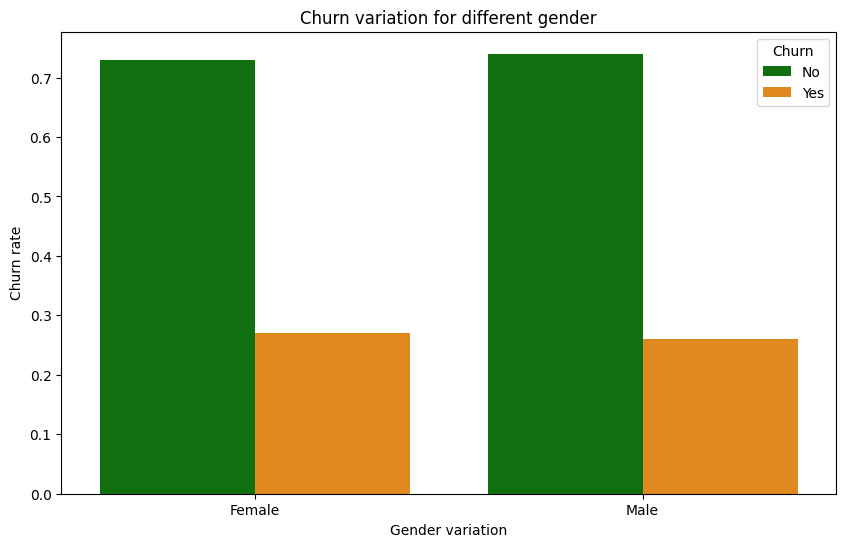

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_variation_by_gender, x='gender', y='proportion', hue='Churn', palette=['green', 'darkorange'])
plt.xlabel("Gender variation")
plt.ylabel("Churn rate")
plt.title("Churn variation for different gender");

#### Comments:
The above analysis indicates that:
* Churn rate is higher for female customers (approximately 27%) compared to male customers (around 26%).

### 2. Are senior citizens more likely to churn?

In [7]:
## Churn rate of senior citizen
churn_rate_of_senior_citizen = df.groupby(['SeniorCitizen'])['Churn'].value_counts(normalize=True).to_frame()

churn_rate_of_senior_citizen

proportion
SeniorCitizen Churn            
0             No       0.763476
              Yes      0.236524
1             No       0.583333
              Yes      0.416667

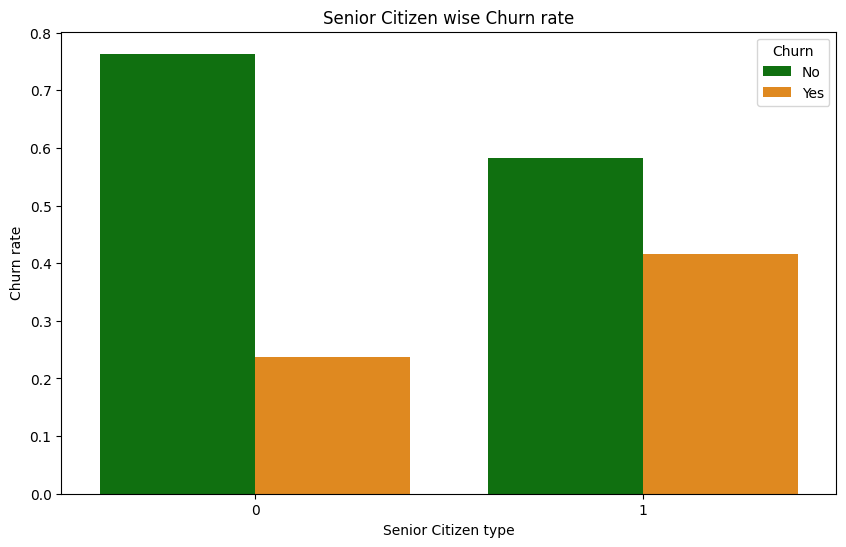

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_rate_of_senior_citizen, x='SeniorCitizen', y='proportion', hue='Churn', palette=['green', 'darkorange'])
plt.xlabel("Senior Citizen type")
plt.ylabel("Churn rate")
plt.title("Senior Citizen wise Churn rate");

#### Comments:
From the above analysis we can clearly see that:
* Senior citizens have a higher churn rate (approximately 41%) compared to non-senior citizens (around 23%). 

This suggests that age may be a factor influencing customer retention, with older customers being more prone to discontinuing the service.

### 3. How does churn differ for customers with partners or dependents?

In [9]:
## How churn vary by customer partner wise
partner_wise_churn_rate = df.groupby(['Partner'])['Churn'].value_counts(normalize=True).round(2).to_frame()

partner_wise_churn_rate

proportion
Partner Churn            
No      No           0.67
        Yes          0.33
Yes     No           0.80
        Yes          0.20

In [10]:
## How churn vary by customer dependents wise
dependents_wise_churn_rate = df.groupby(['Dependents'])['Churn'].value_counts(normalize=True).round(2).to_frame()

dependents_wise_churn_rate

proportion
Dependents Churn            
No         No           0.69
           Yes          0.31
Yes        No           0.84
           Yes          0.16

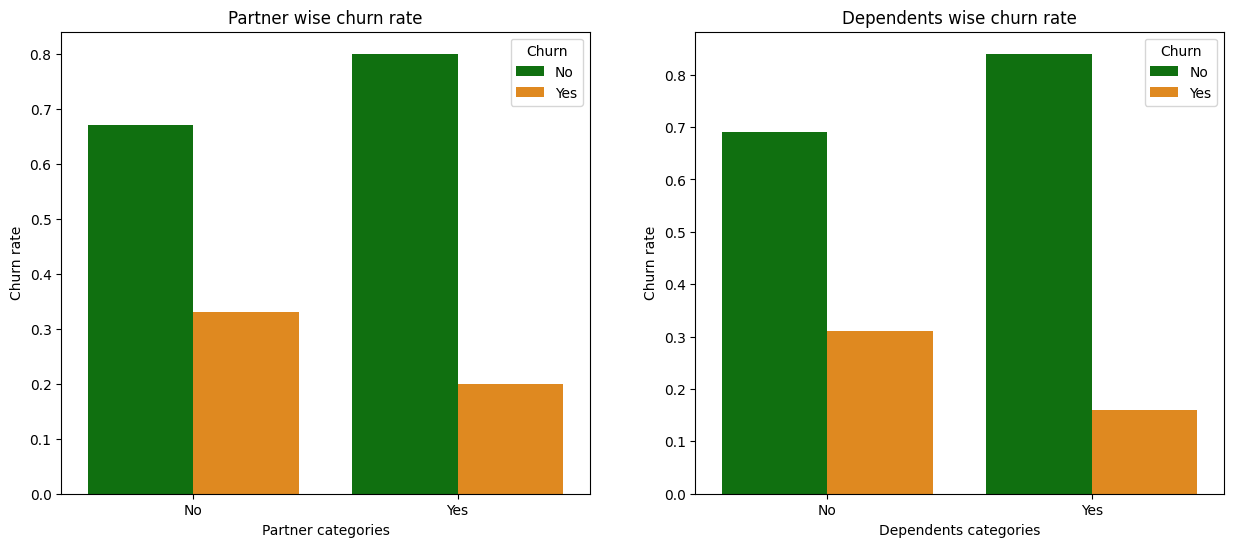

In [11]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.barplot(data=partner_wise_churn_rate, x='Partner', y='proportion', hue='Churn', palette=['green', 'darkorange'])
plt.title("Partner wise churn rate")
plt.xlabel("Partner categories")
plt.ylabel("Churn rate");

plt.subplot(1, 2, 2)
sns.barplot(data=dependents_wise_churn_rate, x='Dependents', y='proportion', hue='Churn', palette=['green', 'darkorange'])
plt.title("Dependents wise churn rate")
plt.xlabel("Dependents categories")
plt.ylabel("Churn rate");

#### Comments:
The above analysis shows that:
* Customers without partners have a higher churn rate (approximately 33%) compared to those with partners (around 20%).
* Similarly, customers without dependents exhibit a higher churn rate (about 31%) than those with dependents (approximately 16%).

### 4. Which demographic group has the highest churn probability?

Understanding churn rate across differnent demographic groups(gender, senior citizen, and contract type) can help in identifying vulnerable segments and tailoring retention strategies accordingly.

In [16]:
demographic_groupwise_churn = pd.pivot_table(data=df, index=['gender', 'SeniorCitizen', 'Partner', 'Dependents'], columns='Churn', aggfunc='size')
demographic_groupwise_churn

Churn                                     No  Yes
gender SeniorCitizen Partner Dependents          
Female 0             No      No          909  428
                             Yes         110   32
                     Yes     No          482  113
                             Yes         710  124
       1             No      No          159  158
                             Yes           2    1
                     Yes     No          136   73
                             Yes          31    8
Male   0             No      No          962  418
                             Yes         166   43
                     Yes     No          438  128
                             Yes         713  105
       1             No      No          126  117
                             Yes           4    1
                     Yes     No          176  105
                             Yes          31   12

In [24]:
groupwise_churn_probability = round(demographic_groupwise_churn['Yes']/(demographic_groupwise_churn['Yes'] + demographic_groupwise_churn['No']), 2).to_frame().reset_index().sort_values(ascending=False, by=[0]).reset_index(drop='index')
groupwise_churn_probability.rename(columns={0 : 'churn_probability'}, inplace=True)
groupwise_churn_probability

,gender,SeniorCitizen,Partner,Dependents,churn_probability
0,Female,1,No,No,0.50
1,Male,1,No,No,0.48
2,Male,1,Yes,No,0.37
3,Female,1,Yes,No,0.35
4,Female,1,No,Yes,0.33
5,Female,0,No,No,0.32
6,Male,0,No,No,0.30
7,Male,1,Yes,Yes,0.28
8,Male,0,Yes,No,0.23
9,Female,0,No,Yes,0.23


#### Comments:
* The analysis shows that there are 16 possible demographic groups of churned customers.
* Among all possible demographic groups the one with the highest churn number is **(Gender: Female, Senior Citizen: Yes, Partner: No, Dependents: No)** with a churn probability of 50%.
* So this demographic group has the highest churn probability and should be targeted for retention efforts.

### 5. Is there a demographic segment that is low churn but high revenue?

In [29]:
churn_rate = lambda x: round((x=='Yes').sum()/len(x), 2)
demographic_segment_with_revenue = df.groupby(['gender' ,'Partner', 'SeniorCitizen', 'Dependents']).agg(
    Churn_Rate=('Churn', churn_rate),
    Total_Revenue=('TotalCharges', 'sum')
).reset_index()

demographic_segment_with_revenue.sort_values(ascending=[True], by=['Churn_Rate'])

,gender,Partner,SeniorCitizen,Dependents,Churn_Rate,Total_Revenue
13,Male,Yes,0,Yes,0.13,2240010.55
5,Female,Yes,0,Yes,0.15,2184824.60
4,Female,Yes,0,No,0.19,1880579.45
11,Male,No,1,Yes,0.20,9422.55
7,Female,Yes,1,Yes,0.21,146323.50
9,Male,No,0,Yes,0.21,291730.55
12,Male,Yes,0,No,0.23,1913301.85
1,Female,No,0,Yes,0.23,176903.35
15,Male,Yes,1,Yes,0.28,181176.05
8,Male,No,0,No,0.30,2053247.35


#### Comments:
The analysis indicates that:
* There is a demographic group **(Gender: Male, Partner: Yes, Senior Citizen: No, Dependents: Yes)** that exhibits a low churn(churn_rate=13%) rate but highest revenue (Total_Revenue=2240010.55) for churned customer. 

This suggests that this segment is valuable to the company, and efforts should be made to retain these customers.

#### Conclusion : 
From this demographic analysis of customers it is clear that the customer group **(Gender: Female, Senior Citizen: Yes, Partner: No, Dependents: No)** has the highest churn probability (approximately 50%). That means that 50 out of 100 customers of this group are churning out.

On the other hand, customer group **(Gender: Male, Partner: Yes, Senior Citizen: No, Dependents: Yes)** has low churn but highest revenue (Total_Revenue=2240010.55) for churned customer. This group can be targated for upselling.

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)